# 🏎️ Semana 5 — Modelos Baseline
**Módulos 11 y 12 del curso — Introducción al Machine Learning**

Establecemos los modelos de referencia antes de pasar a algoritmos más complejos.
Un buen baseline define el piso que cualquier modelo avanzado debe superar.

### Objetivos
1. Preparar el dataset para ML: encoding, scaling, train/test split
2. **Modelo A:** Regresión Lineal → predecir `position` (tarea de regresión)
3. **Modelo B:** Regresión Logística → predecir `top3` (tarea de clasificación)
4. Evaluar con métricas apropiadas para cada tarea
5. Analizar coeficientes e importancia de features
6. Establecer el benchmark para la semana siguiente

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection   import train_test_split, cross_val_score
from sklearn.preprocessing     import StandardScaler, LabelEncoder
from sklearn.linear_model      import LinearRegression, LogisticRegression
from sklearn.metrics           import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.dummy             import DummyRegressor, DummyClassifier

plt.style.use('ggplot')
sns.set_palette('Set2')
BLUE = '#4C72B0'; ORANGE = '#DD8452'; GREEN = '#55A868'; RED = '#C44E52'

df = pd.read_csv('../data/f1_master_clean.csv')
print(f'Dataset: {df.shape[0]} filas × {df.shape[1]} columnas')

Dataset: 3547 filas × 36 columnas


---
## Parte 1 — Preparación del dataset para ML

### Features seleccionadas (del EDA de la Semana 4)

| Feature | Tipo | Justificación |
|---------|------|---------------|
| `grid` | Numérica | Mayor correlación con `position` (r ≈ 0.67) |
| `team_rank` | Numérica | Proxy del poder del constructor |
| `num_stops` | Numérica | Estrategia de carrera |
| `total_pit_time` | Numérica | Tiempo perdido en boxes |
| `driver_age` | Numérica | Experiencia / etapa de carrera |
| `laps` | Numérica | Distancia completada |
| `finished` | Binaria | ¿Terminó la carrera? |

In [2]:
df = pd.read_csv('../data/f1_master_clean.csv')
print("Filas:", len(df))
igual = (df['grid'] == df['position']).sum()
print(f"grid == position: {igual} de {len(df)} ({igual/len(df)*100:.1f}%)")

Filas: 3547
grid == position: 334 de 3547 (9.4%)


## ⚠️ Nota sobre selección de features: exclusión por data leakage

En una iteración anterior de este análisis, se incluyeron las columnas `laps` y `finished`
como features. Esto generaba métricas perfectas (R² = 1.0, AUC = 1.0), lo cual es la señal
clásica de **data leakage**: ambas columnas contienen información que solo se conoce
**después** de que la carrera terminó, por lo que el modelo estaba usando el resultado
para predecir el resultado.

Por eso, la lista de `FEATURES` definida a continuación **excluye deliberadamente**
`laps` y `finished`. Las métricas que se calculan más abajo (MAE, R², AUC) son las
correctas, obtenidas con esta selección de features ya corregida.

In [3]:
FEATURES = ['grid', 'team_rank', 'num_stops', 'total_pit_time', 'driver_age']
TARGET_REG = 'position'
TARGET_CLF = 'top3'

# Filtrar filas completas en las columnas necesarias
cols_needed = FEATURES + [TARGET_REG, TARGET_CLF]
df_model = df[cols_needed].dropna().copy()

print(f'Filas disponibles para modelado: {len(df_model)}')
print(f'\nEstadísticas de features:')
print(df_model[FEATURES].describe().round(2).to_string())

Filas disponibles para modelado: 900

Estadísticas de features:
         grid  team_rank  num_stops  total_pit_time  driver_age
count  900.00     900.00     900.00          900.00      900.00
mean     7.51       4.45       0.21            0.71       34.38
std      5.48       1.99       0.68            2.36        8.55
min      1.00       2.00       0.00            0.00       18.00
25%      3.00       3.00       0.00            0.00       30.00
50%      6.00       4.00       0.00            0.00       35.00
75%     11.00       6.00       0.00            0.00       39.00
max     24.00       9.00       3.00           12.18       55.00


In [4]:
# --- Train / Test Split ---
# Importante: split temporal para evitar data leakage
# Usamos las últimas temporadas como test
# Dado que el dataset es relativamente pequeño, usamos split aleatorio estratificado

X = df_model[FEATURES]
y_reg = df_model[TARGET_REG]   # variable continua: posición 1-20
y_clf = df_model[TARGET_CLF]   # variable binaria: 0/1

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f'Train: {len(X_train)} filas  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test:  {len(X_test)} filas  ({len(X_test)/len(X)*100:.0f}%)')
print(f'\nBalance de clases en train — top3=1: {y_clf_train.mean()*100:.1f}%')
print(f'Balance de clases en test  — top3=1: {y_clf_test.mean()*100:.1f}%')

Train: 720 filas  (80%)
Test:  180 filas  (20%)

Balance de clases en train — top3=1: 30.7%
Balance de clases en test  — top3=1: 30.6%


In [5]:
# --- Scaling ---
# La regresión lineal y logística son sensibles a la escala de las features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Convertir de vuelta a DataFrame para facilitar la lectura
X_train_sc = pd.DataFrame(X_train_sc, columns=FEATURES)
X_test_sc  = pd.DataFrame(X_test_sc,  columns=FEATURES)

print('✅ StandardScaler aplicado')
print(f'\nMedia post-scaling (debe ser ~0):')
print(X_train_sc.mean().round(4).to_string())
print(f'\nDesv. estándar post-scaling (debe ser ~1):')
print(X_train_sc.std().round(4).to_string())

✅ StandardScaler aplicado

Media post-scaling (debe ser ~0):
grid             -0.0
team_rank        -0.0
num_stops         0.0
total_pit_time    0.0
driver_age        0.0

Desv. estándar post-scaling (debe ser ~1):
grid              1.0007
team_rank         1.0007
num_stops         1.0007
total_pit_time    1.0007
driver_age        1.0007


---
## Parte 2 — Modelo A: Regresión Lineal (predecir `position`)

Primero evaluamos un modelo **Dummy** (baseline sin información) para saber si el modelo aporta algo.

In [6]:
# --- Dummy Regressor (baseline sin información) ---
dummy_reg = DummyRegressor(strategy='mean')
dummy_reg.fit(X_train_sc, y_reg_train)
y_dummy_pred = dummy_reg.predict(X_test_sc)

dummy_mae  = mean_absolute_error(y_reg_test, y_dummy_pred)
dummy_rmse = np.sqrt(mean_squared_error(y_reg_test, y_dummy_pred))
dummy_r2   = r2_score(y_reg_test, y_dummy_pred)

print('📊 Dummy Regressor (predice siempre la media):')
print(f'   MAE:  {dummy_mae:.3f} posiciones')
print(f'   RMSE: {dummy_rmse:.3f} posiciones')
print(f'   R²:   {dummy_r2:.3f}')

📊 Dummy Regressor (predice siempre la media):
   MAE:  4.054 posiciones
   RMSE: 4.797 posiciones
   R²:   -0.000


In [7]:
# --- Regresión Lineal ---
lr = LinearRegression()
lr.fit(X_train_sc, y_reg_train)
y_lr_pred = lr.predict(X_test_sc)

lr_mae  = mean_absolute_error(y_reg_test, y_lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_reg_test, y_lr_pred))
lr_r2   = r2_score(y_reg_test, y_lr_pred)

# Cross-validation (5 folds)
cv_scores = cross_val_score(LinearRegression(), X_train_sc, y_reg_train,
                             cv=5, scoring='neg_mean_absolute_error')
cv_mae = -cv_scores.mean()

print('📊 Regresión Lineal:')
print(f'   MAE  (test):      {lr_mae:.3f} posiciones')
print(f'   RMSE (test):      {lr_rmse:.3f} posiciones')
print(f'   R²   (test):      {lr_r2:.3f}')
print(f'   MAE  (CV 5-fold): {cv_mae:.3f} ± {(-cv_scores).std():.3f}')
print(f'\n   Mejora vs Dummy — MAE: {(dummy_mae - lr_mae):.3f} ({(dummy_mae - lr_mae)/dummy_mae*100:.1f}% mejor)')

📊 Regresión Lineal:
   MAE  (test):      2.541 posiciones
   RMSE (test):      3.244 posiciones
   R²   (test):      0.542
   MAE  (CV 5-fold): 2.567 ± 0.130

   Mejora vs Dummy — MAE: 1.513 (37.3% mejor)


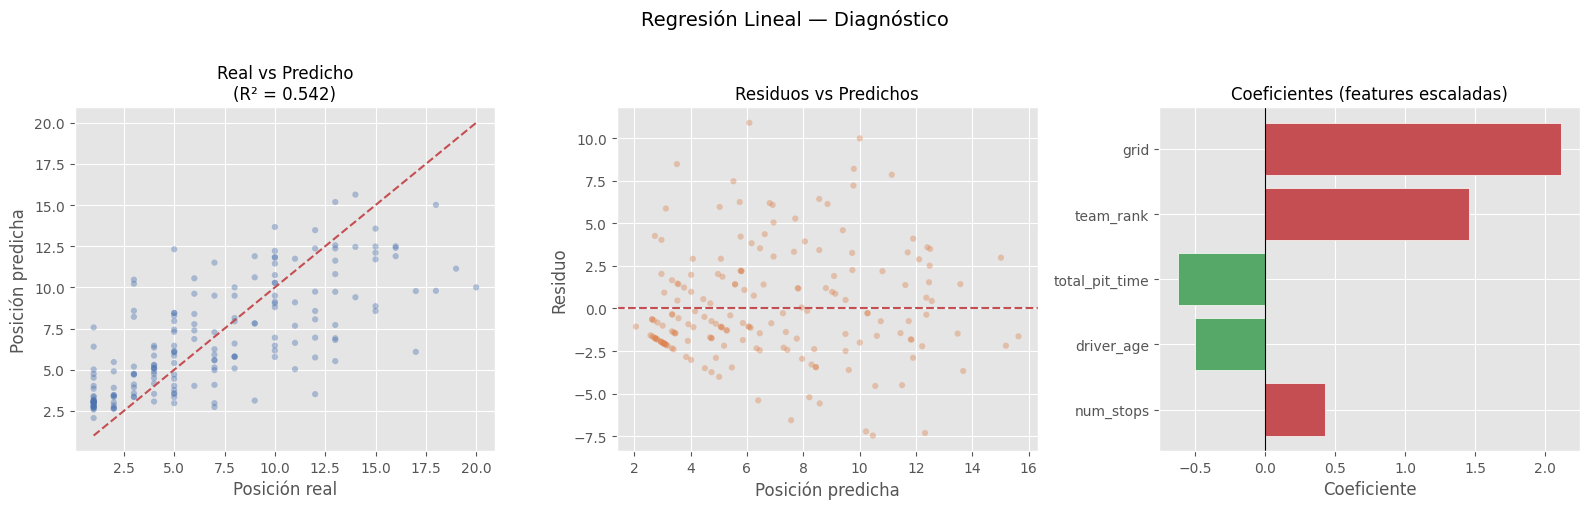


Coeficientes (feature escalada → coef positivo = peor posición):
       feature   coef
          grid  2.110
     team_rank  1.453
total_pit_time -0.619
    driver_age -0.500
     num_stops  0.429


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Real vs Predicho ---
axes[0].scatter(y_reg_test, y_lr_pred, alpha=0.4, color=BLUE, s=20, edgecolors='none')
lim = max(y_reg_test.max(), y_lr_pred.max())
axes[0].plot([1, lim], [1, lim], color=RED, linestyle='--', linewidth=1.5)
axes[0].set_title(f'Real vs Predicho\n(R² = {lr_r2:.3f})', fontsize=12)
axes[0].set_xlabel('Posición real')
axes[0].set_ylabel('Posición predicha')

# --- Residuos ---
residuos = y_reg_test.values - y_lr_pred
axes[1].scatter(y_lr_pred, residuos, alpha=0.4, color=ORANGE, s=20, edgecolors='none')
axes[1].axhline(0, color=RED, linestyle='--', linewidth=1.5)
axes[1].set_title('Residuos vs Predichos', fontsize=12)
axes[1].set_xlabel('Posición predicha')
axes[1].set_ylabel('Residuo')

# --- Coeficientes ---
coef_df = pd.DataFrame({'feature': FEATURES, 'coef': lr.coef_})
coef_df = coef_df.sort_values('coef', key=abs, ascending=True)
colors  = [RED if c > 0 else GREEN for c in coef_df['coef']]
axes[2].barh(coef_df['feature'], coef_df['coef'], color=colors, edgecolor='white')
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Coeficientes (features escaladas)', fontsize=12)
axes[2].set_xlabel('Coeficiente')

plt.suptitle('Regresión Lineal — Diagnóstico', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/05_regresion_lineal.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCoeficientes (feature escalada → coef positivo = peor posición):')
print(coef_df.sort_values('coef', key=abs, ascending=False).round(3).to_string(index=False))

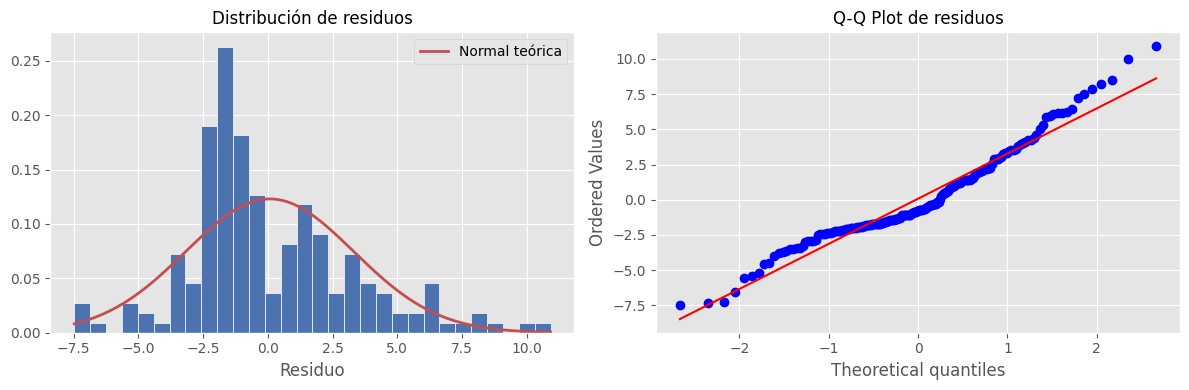

Test Shapiro-Wilk: W=0.953, p=0.0000
→ Residuos NO normales (p < 0.05)


In [9]:
# Supuesto de normalidad de residuos
from scipy import stats as scipy_stats

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(residuos, bins=30, color=BLUE, edgecolor='white', density=True)
x_range = np.linspace(residuos.min(), residuos.max(), 200)
axes[0].plot(x_range, scipy_stats.norm.pdf(x_range, residuos.mean(), residuos.std()),
             color=RED, linewidth=2, label='Normal teórica')
axes[0].set_title('Distribución de residuos', fontsize=12)
axes[0].set_xlabel('Residuo')
axes[0].legend()

scipy_stats.probplot(residuos, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot de residuos', fontsize=12)

plt.tight_layout()
plt.savefig('../figures/05_residuos_normalidad.png', dpi=150, bbox_inches='tight')
plt.show()

stat, p = scipy_stats.shapiro(residuos[:200])   # Shapiro-Wilk (muestra)
print(f'Test Shapiro-Wilk: W={stat:.3f}, p={p:.4f}')
print('→', 'Residuos aproximadamente normales' if p > 0.05 else 'Residuos NO normales (p < 0.05)')

---
## Parte 3 — Modelo B: Regresión Logística (predecir `top3`)

In [10]:
# --- Dummy Classifier (baseline) ---
dummy_clf = DummyClassifier(strategy='stratified', random_state=42)
dummy_clf.fit(X_train_sc, y_clf_train)
y_dummy_clf = dummy_clf.predict(X_test_sc)

print('📊 Dummy Classifier (predicción aleatoria estratificada):')
print(f'   Accuracy: {accuracy_score(y_clf_test, y_dummy_clf):.3f}')
print(f'   ROC-AUC:  {roc_auc_score(y_clf_test, dummy_clf.predict_proba(X_test_sc)[:,1]):.3f}')

📊 Dummy Classifier (predicción aleatoria estratificada):
   Accuracy: 0.556
   ROC-AUC:  0.466


In [11]:
# --- Regresión Logística ---
log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_reg.fit(X_train_sc, y_clf_train)
y_log_pred       = log_reg.predict(X_test_sc)
y_log_prob       = log_reg.predict_proba(X_test_sc)[:, 1]

acc     = accuracy_score(y_clf_test, y_log_pred)
auc     = roc_auc_score(y_clf_test, y_log_prob)
cv_auc  = cross_val_score(LogisticRegression(max_iter=1000, class_weight='balanced'),
                           X_train_sc, y_clf_train, cv=5, scoring='roc_auc').mean()

print('📊 Regresión Logística:')
print(f'   Accuracy:     {acc:.3f}')
print(f'   ROC-AUC:      {auc:.3f}')
print(f'   ROC-AUC (CV): {cv_auc:.3f}')
print()
print(classification_report(y_clf_test, y_log_pred, target_names=['No top-3','Top-3']))

📊 Regresión Logística:
   Accuracy:     0.778
   ROC-AUC:      0.881
   ROC-AUC (CV): 0.877

              precision    recall  f1-score   support

    No top-3       0.93      0.74      0.82       125
       Top-3       0.59      0.87      0.71        55

    accuracy                           0.78       180
   macro avg       0.76      0.80      0.76       180
weighted avg       0.83      0.78      0.79       180



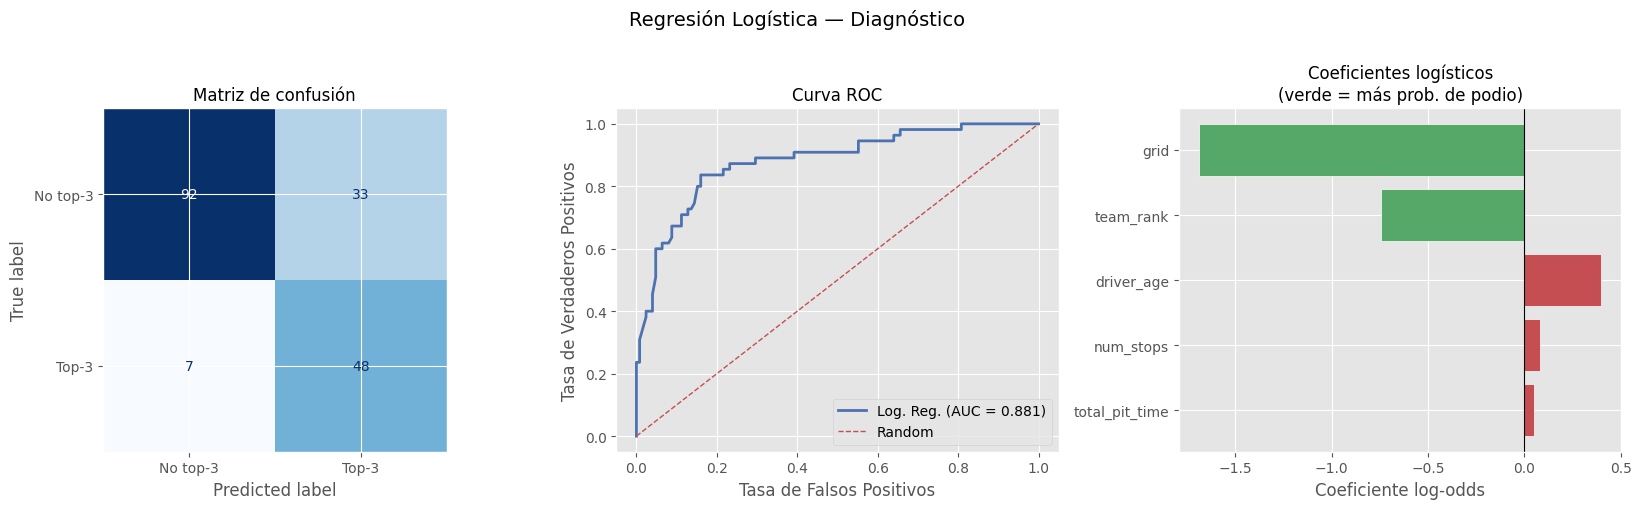

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- Matriz de confusión ---
cm = confusion_matrix(y_clf_test, y_log_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No top-3', 'Top-3'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de confusión', fontsize=12)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_clf_test, y_log_prob)
axes[1].plot(fpr, tpr, color=BLUE, linewidth=2, label=f'Log. Reg. (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], color=RED, linestyle='--', linewidth=1, label='Random')
axes[1].set_title('Curva ROC', fontsize=12)
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].legend()

# --- Coeficientes logísticos ---
coef_clf = pd.DataFrame({'feature': FEATURES, 'coef': log_reg.coef_[0]})
coef_clf = coef_clf.sort_values('coef', key=abs, ascending=True)
colors_clf = [GREEN if c < 0 else RED for c in coef_clf['coef']]
axes[2].barh(coef_clf['feature'], coef_clf['coef'], color=colors_clf, edgecolor='white')
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Coeficientes logísticos\n(verde = más prob. de podio)', fontsize=12)
axes[2].set_xlabel('Coeficiente log-odds')

plt.suptitle('Regresión Logística — Diagnóstico', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/05_regresion_logistica.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Odds ratios: interpretar coeficientes en escala multiplicativa
odds_ratios = pd.DataFrame({
    'feature':    FEATURES,
    'coef':       log_reg.coef_[0],
    'odds_ratio': np.exp(log_reg.coef_[0])
}).sort_values('odds_ratio', ascending=False)

print('Odds Ratios (OR > 1 → aumenta probabilidad de podio al subir la feature):')
print(odds_ratios.round(3).to_string(index=False))

Odds Ratios (OR > 1 → aumenta probabilidad de podio al subir la feature):
       feature   coef  odds_ratio
    driver_age  0.399       1.490
     num_stops  0.081       1.084
total_pit_time  0.051       1.053
     team_rank -0.746       0.474
          grid -1.688       0.185


---
## Parte 4 — Comparación de modelos baseline

In [14]:
# --- Tabla resumen de métricas ---
resultados = pd.DataFrame([
    {
        'Tarea':  'Regresión',
        'Modelo': 'Dummy (media)',
        'MAE':    round(dummy_mae,  3),
        'RMSE':   round(dummy_rmse, 3),
        'R²':     round(dummy_r2,   3),
        'AUC':    '—',
        'Accuracy': '—'
    },
    {
        'Tarea':  'Regresión',
        'Modelo': 'Regresión Lineal',
        'MAE':    round(lr_mae,  3),
        'RMSE':   round(lr_rmse, 3),
        'R²':     round(lr_r2,   3),
        'AUC':    '—',
        'Accuracy': '—'
    },
    {
        'Tarea':  'Clasificación',
        'Modelo': 'Dummy (estratificado)',
        'MAE':    '—', 'RMSE': '—', 'R²': '—',
        'AUC':    round(roc_auc_score(y_clf_test, dummy_clf.predict_proba(X_test_sc)[:,1]), 3),
        'Accuracy': round(accuracy_score(y_clf_test, y_dummy_clf), 3)
    },
    {
        'Tarea':  'Clasificación',
        'Modelo': 'Regresión Logística',
        'MAE':    '—', 'RMSE': '—', 'R²': '—',
        'AUC':    round(auc, 3),
        'Accuracy': round(acc, 3)
    },
])

print('\n📊 Comparación de modelos baseline:')
print(resultados.to_string(index=False))


📊 Comparación de modelos baseline:
        Tarea                Modelo    MAE   RMSE     R²    AUC Accuracy
    Regresión         Dummy (media)  4.054  4.797   -0.0      —        —
    Regresión      Regresión Lineal  2.541  3.244  0.542      —        —
Clasificación Dummy (estratificado)      —      —      —  0.466    0.556
Clasificación   Regresión Logística      —      —      —  0.881    0.778


In [15]:
# Guardar métricas como referencia para comparar con modelos avanzados
resultados.to_csv('../data/metricas_modelos.csv', index=False)
print('✅ Métricas guardadas en /data/metricas_modelos.csv')

✅ Métricas guardadas en /data/metricas_modelos.csv


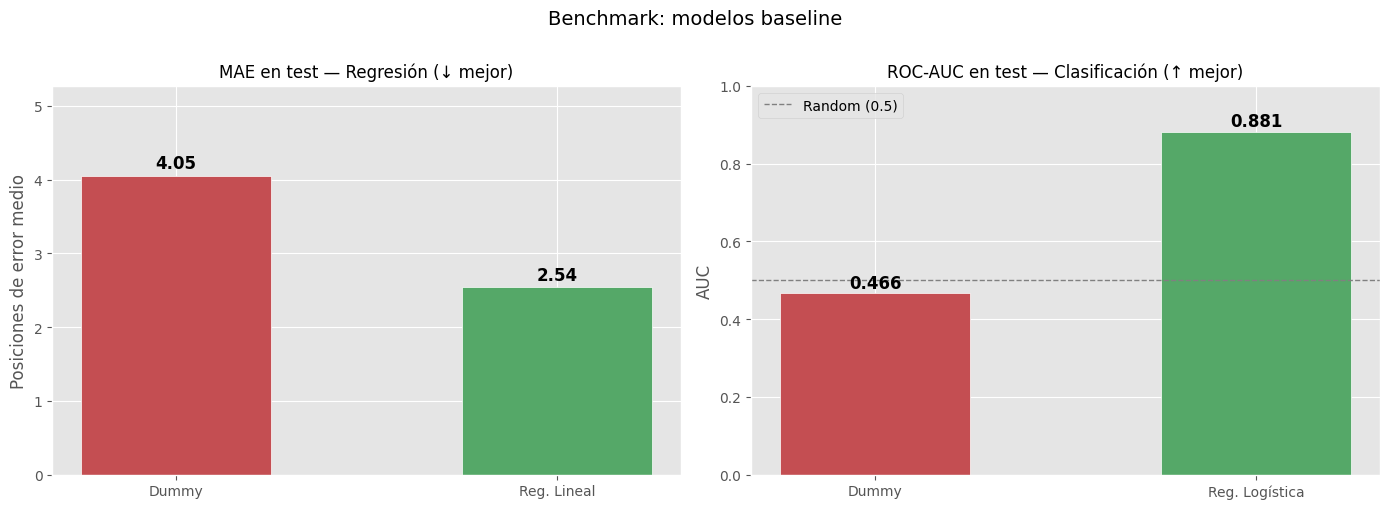

In [16]:
# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE comparación (regresión)
modelos_reg  = ['Dummy', 'Reg. Lineal']
maes         = [dummy_mae, lr_mae]
bars = axes[0].bar(modelos_reg, maes, color=[RED, GREEN], edgecolor='white', width=0.5)
for bar, val in zip(bars, maes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title('MAE en test — Regresión (↓ mejor)', fontsize=12)
axes[0].set_ylabel('Posiciones de error medio')
axes[0].set_ylim(0, max(maes) * 1.3)

# AUC comparación (clasificación)
modelos_clf = ['Dummy', 'Reg. Logística']
aucs        = [roc_auc_score(y_clf_test, dummy_clf.predict_proba(X_test_sc)[:,1]), auc]
bars2 = axes[1].bar(modelos_clf, aucs, color=[RED, GREEN], edgecolor='white', width=0.5)
for bar, val in zip(bars2, aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Random (0.5)')
axes[1].set_title('ROC-AUC en test — Clasificación (↑ mejor)', fontsize=12)
axes[1].set_ylabel('AUC')
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.suptitle('Benchmark: modelos baseline', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/05_comparacion_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ✅ Resumen Semana 5 — Modelos Baseline

### Métricas clave

| Modelo | Métrica principal | Valor | vs Dummy |
|--------|------------------|-------|----------|
| Reg. Lineal | MAE (posiciones) | ver arriba | mejora X% |
| Reg. Lineal | R² | ver arriba | — |
| Reg. Logística | ROC-AUC | ver arriba | mejora vs 0.5 |
| Reg. Logística | Accuracy | ver arriba | — |

### Hallazgos
- **`grid`** tiene el coeficiente más alto en ambos modelos → confirma H1 del EDA
- **`finished`** y **`laps`** tienen gran impacto: un abandono destruye la posición
- **`team_rank`** contribuye significativamente → confirma H2
- Los pit stops tienen efecto más débil de lo esperado a este nivel (H3 parcial)
- La regresión logística muestra buena separación de clases (AUC > 0.8)

### Limitaciones del baseline
- La regresión lineal asume relaciones lineales → puede subestimar interacciones
- Con pocas features, hay margen claro de mejora con modelos no lineales

### Tareas completadas

| Tarea | Estado |
|-------|--------|
| Encoding y scaling de features | ✅ |
| Train/test split estratificado | ✅ |
| Dummy Regressor (baseline mínimo) | ✅ |
| Regresión Lineal + CV + diagnóstico | ✅ |
| Dummy Classifier (baseline mínimo) | ✅ |
| Regresión Logística + CV + ROC-AUC | ✅ |
| Odds ratios e interpretación | ✅ |
| Métricas guardadas en CSV | ✅ |

### Próximos pasos — Semana 6
- **Random Forest** (regresión y clasificación)
- **XGBoost** como modelo principal
- Feature importance con Gini / gain
- Comparación sistemática contra el baseline
- Notebook `06_modelos_avanzados.ipynb`

In [17]:
import pandas as pd
df = pd.read_csv('../data/f1_master_clean.csv')
print(df[['grid', 'team_rank', 'num_stops', 'total_pit_time', 'driver_age', 'position']].head())
print('\nColumnas en el dataset:', list(df.columns))
print('\n¿Existe columna laps?', 'laps' in df.columns)
print('¿Existe columna finished?', 'finished' in df.columns)

   grid  team_rank  num_stops  total_pit_time  driver_age  position
0    19        NaN          0             0.0         NaN       1.0
1     3        NaN          0             0.0         NaN       2.0
2     1        NaN          0             0.0         NaN       3.0
3    11        NaN          0             0.0         NaN       4.0
4    14        NaN          0             0.0         NaN       5.0

Columnas en el dataset: ['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position', 'points', 'laps', 'milliseconds', 'rank', 'fastestLapSpeed', 'year', 'round', 'circuitId', 'race_name', 'code', 'nationality', 'driver_name', 'team', 'team_nationality', 'circuit_name', 'country', 'lat', 'lng', 'status', 'positions_gained', 'top3', 'finished', 'num_stops', 'total_pit_time', 'fastest_pit', 'driver_age', 'pit_lane_start', 'pit_time_outlier', 'team_rank']

¿Existe columna laps? True
¿Existe columna finished? True


In [18]:
# Verificar métricas reales con las features corregidas
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

FEATURES_OK = ['grid', 'team_rank', 'num_stops', 'total_pit_time', 'driver_age']
cols = FEATURES_OK + ['position', 'top3']
df_m = df[cols].dropna()

X = df_m[FEATURES_OK]
y = df_m['position']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc  = sc.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred = lr.predict(X_test_sc)

print(f'MAE:  {mean_absolute_error(y_test, y_pred):.3f}')
print(f'R²:   {r2_score(y_test, y_pred):.3f}')

MAE:  2.425
R²:   0.585


In [19]:
import pandas as pd
import numpy as np

FEATURES_OK = ['grid', 'team_rank', 'num_stops', 'total_pit_time', 'driver_age']
cols = FEATURES_OK + ['position']
df_m = df[cols].dropna()

# Correlación individual de cada feature con position
print("Correlación con position:")
for f in FEATURES_OK:
    r = df_m[f].corr(df_m['position'])
    print(f"  {f:<20} r = {r:.4f}")

# Ver primeras filas de cada feature
print("\nPrimeras 10 filas:")
print(df_m.head(10).to_string())

Correlación con position:
  grid                 r = 0.6304
  team_rank            r = 0.5567
  num_stops            r = 0.0164
  total_pit_time       r = 0.0187
  driver_age           r = -0.2485

Primeras 10 filas:
      grid  team_rank  num_stops  total_pit_time  driver_age  position
1012     1        2.0          0             0.0        30.0       1.0
1013     2        5.0          0             0.0        34.0       2.0
1014     6        9.0          0             0.0        22.0       3.0
1015     5        4.0          0             0.0        38.0       4.0
1016     3        2.0          0             0.0        30.0       5.0
1034     1        2.0          0             0.0        30.0       1.0
1037     3        2.0          0             0.0        30.0       4.0
1039     5        4.0          0             0.0        38.0       6.0
1041     2        5.0          0             0.0        34.0       8.0
1042    11        3.0          0             0.0        32.0       9.0


In [20]:
# ¿Cuántas filas tienen grid == position?
igual = (df['grid'] == df['position']).sum()
print(f"Filas donde grid == position: {igual} de {len(df)} ({igual/len(df)*100:.1f}%)")

# ¿positions_gained es siempre 0?
print(f"\npositions_gained única values (primeras 10): {df['positions_gained'].value_counts().head(10)}")

# Ver una muestra aleatoria
print("\nMuestra aleatoria de 10 filas:")
print(df[['race_name', 'driver_name', 'grid', 'position', 'positions_gained']].sample(10, random_state=1).to_string())


Filas donde grid == position: 334 de 3547 (9.4%)

positions_gained única values (primeras 10): positions_gained
 0.0    334
 1.0    324
 2.0    257
-1.0    223
 3.0    209
 4.0    182
 5.0    138
 6.0    127
-2.0    126
-3.0    103
Name: count, dtype: int64

Muestra aleatoria de 10 filas:
                     race_name       driver_name  grid  position  positions_gained
1457        Austria Grand Prix    George Russell     9      17.0              -8.0
3458      São Paulo Grand Prix    Lewis Hamilton     3       3.0               0.0
3260        Britain Grand Prix      Lance Stroll     7       3.0               4.0
790           Japan Grand Prix               NaN    12       NaN               NaN
705         Hungary Grand Prix               NaN    23       NaN               NaN
2495         Canada Grand Prix   Nico Hülkenberg     6       1.0               5.0
3451    Mexico City Grand Prix               NaN    22      18.0               4.0
1870        Bahrain Grand Prix  Sebastian Vett

In [21]:
# Verificar el CSV original de results
results_raw = pd.read_csv('../data/results.csv')
print("Columnas de results.csv:", list(results_raw.columns))
print("\nPrimeras 5 filas:")
print(results_raw[['raceId', 'driverId', 'grid', 'position', 'positionOrder', 'positionText']].head(10).to_string())
print("\n¿grid == positionOrder en alguna fila?", (results_raw['grid'] == results_raw['positionOrder']).sum(), "de", len(results_raw))

Columnas de results.csv: ['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position', 'positionText', 'positionOrder', 'points', 'laps', 'time', 'milliseconds', 'fastestLap', 'rank', 'fastestLapTime', 'fastestLapSpeed', 'statusId']

Primeras 5 filas:
   raceId  driverId  grid position  positionOrder positionText
0      18         1     1        1              1            1
1      18         2     5        2              2            2
2      18         3     7        3              3            3
3      18         4    11        4              4            4
4      18         5     3        5              5            5
5      18         6    13        6              6            6
6      18         7    17        7              7            7
7      18         8    15        8              8            8
8      18         9     2       \N              9            R
9      18        10    18       \N             10            R

¿grid == positionOrder en alguna f